# Phase 2 — EDA Under the New Split Strategy

This notebook performs EDA under the revised Phase 1 design. Cleveland train is the primary development data. Cleveland validation is inspected only as an internal development holdout. Cleveland test remains untouched for modeling decisions. Hungarian and Swiss are inspected for covariate shift because domain adaptation is a core contribution, but their labels should not drive model tuning.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

COLUMN_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal", "target",
]
RAW_FEATURES = [c for c in COLUMN_NAMES if c != "target"]

SITE_FILES = {
    "cleveland": {
        "filename": "processed.cleveland.data",
        "url": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    },
    "hungarian": {
        "filename": "processed.hungarian.data",
        "url": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    },
    "swiss": {
        "filename": "processed.switzerland.data",
        "url": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data",
    },
}

def ensure_raw_files():
    RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    paths = {}
    for site, info in SITE_FILES.items():
        path = RAW_DATA_DIR / info["filename"]
        paths[site] = path
        if not path.exists() or path.stat().st_size == 0:
            print(f"Downloading {site}...")
            urlretrieve(info["url"], path)
    return paths

def load_site(path, site):
    df = pd.read_csv(path, header=None, names=COLUMN_NAMES, na_values="?")
    for col in COLUMN_NAMES:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["target_original"] = df["target"]
    df["target"] = (df["target"] > 0).astype(int)
    df["site"] = site
    df["original_index"] = df.index
    return df

def load_all_sites():
    paths = ensure_raw_files()
    return {site: load_site(path, site) for site, path in paths.items()}

def split_cleveland_v2(cleveland, random_state=RANDOM_STATE):
    # UCI processed Cleveland has no explicit patient ID. Therefore, rows are treated as independent patients.
    # If a patient_id column becomes available later, replace this with GroupShuffleSplit.
    cleveland = cleveland.copy()

    sss_test = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=random_state)
    rest_idx, test_idx = next(sss_test.split(cleveland, cleveland["target"]))

    rest = cleveland.iloc[rest_idx].copy()
    test = cleveland.iloc[test_idx].copy()

    # Validation is 15% of total. After removing 15% test, validation is 15/85 of the remaining rows.
    val_fraction_of_rest = 0.15 / 0.85
    sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction_of_rest, random_state=random_state)
    train_rel_idx, val_rel_idx = next(sss_val.split(rest, rest["target"]))

    train = rest.iloc[train_rel_idx].copy()
    validation = rest.iloc[val_rel_idx].copy()

    train["partition"] = "train"
    validation["partition"] = "validation"
    test["partition"] = "test"

    return train, validation, test

def verify_no_overlap(train, validation, test):
    sets = {
        "train": set(train["original_index"]),
        "validation": set(validation["original_index"]),
        "test": set(test["original_index"]),
    }
    assert sets["train"].isdisjoint(sets["validation"])
    assert sets["train"].isdisjoint(sets["test"])
    assert sets["validation"].isdisjoint(sets["test"])
    print("No Cleveland original_index overlap across train/validation/test.")

def load_phase1_v2_in_memory():
    sites = load_all_sites()
    train, validation, test = split_cleveland_v2(sites["cleveland"])
    verify_no_overlap(train, validation, test)
    return {
        "cleveland_full": sites["cleveland"],
        "cleveland_train": train,
        "cleveland_validation": validation,
        "cleveland_test": test,
        "hungarian": sites["hungarian"],
        "swiss": sites["swiss"],
    }

In [3]:
phase1 = load_phase1_v2_in_memory()
train = phase1["cleveland_train"].copy()
validation = phase1["cleveland_validation"].copy()
test = phase1["cleveland_test"].copy()
hungarian = phase1["hungarian"].copy()
swiss = phase1["swiss"].copy()

splits = {
    "Cleveland train": train,
    "Cleveland validation": validation,
    "Cleveland test (locked)": test,
    "Hungarian external": hungarian,
    "Swiss external": swiss,
}

for name, df in splits.items():
    print(f"{name:26s} rows={len(df):3d}, positive_rate={df['target'].mean():.2%}")

No Cleveland original_index overlap across train/validation/test.
Cleveland train            rows=211, positive_rate=45.97%
Cleveland validation       rows= 46, positive_rate=45.65%
Cleveland test (locked)    rows= 46, positive_rate=45.65%
Hungarian external         rows=294, positive_rate=36.05%
Swiss external             rows=123, positive_rate=93.50%


## Class balance

Class balance is computed for documentation. Resampling or class weighting decisions should be based only on Cleveland train/validation, never on the held-out Cleveland test or external test labels.

In [4]:
class_balance = pd.DataFrame([
    {
        "split": name,
        "rows": len(df),
        "negative": int((df["target"] == 0).sum()),
        "positive": int((df["target"] == 1).sum()),
        "positive_rate": df["target"].mean(),
    }
    for name, df in splits.items()
])
class_balance

,split,rows,negative,positive,positive_rate
0,Cleveland train,211,114,97,0.459716
1,Cleveland validation,46,25,21,0.456522
2,Cleveland test (locked),46,25,21,0.456522
3,Hungarian external,294,188,106,0.360544
4,Swiss external,123,8,115,0.934959


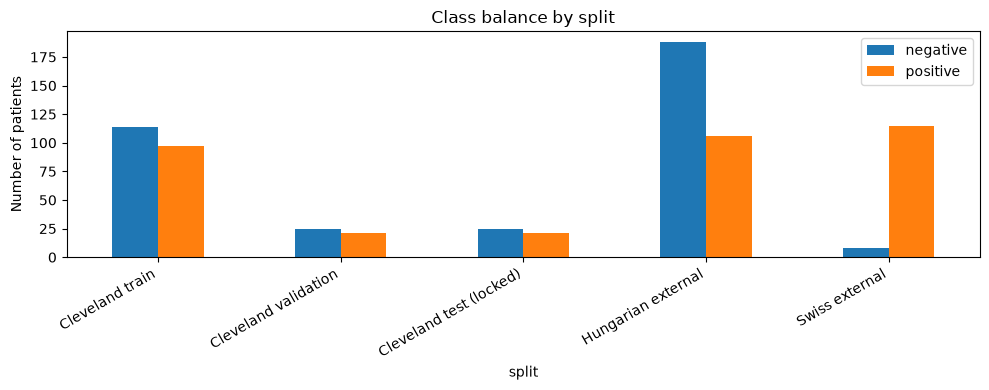

In [5]:
ax = class_balance.set_index("split")[["negative", "positive"]].plot(kind="bar", figsize=(10, 4))
ax.set_title("Class balance by split")
ax.set_ylabel("Number of patients")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Missingness

Missingness is important because preprocessing in Phase 3 must fit the imputer only on Cleveland train. The external sets can be summarized to understand transfer difficulty, but their missingness must not be used to fit preprocessing.

In [6]:
missing_rows = []
for name, df in splits.items():
    for col in RAW_FEATURES:
        missing_rows.append({
            "split": name,
            "feature": col,
            "missing_count": int(df[col].isna().sum()),
            "missing_rate": df[col].isna().mean(),
        })
missingness_summary = pd.DataFrame(missing_rows)
missingness_summary.pivot(index="feature", columns="split", values="missing_rate")

split,Cleveland test (locked),Cleveland train,Cleveland validation,Hungarian external,Swiss external
feature,,,,,
age,0.000000,0.000000,0.0,0.000000,0.000000
ca,0.065217,0.004739,0.0,0.989796,0.959350
chol,0.000000,0.000000,0.0,0.078231,0.000000
cp,0.000000,0.000000,0.0,0.000000,0.000000
exang,0.000000,0.000000,0.0,0.003401,0.008130
fbs,0.000000,0.000000,0.0,0.027211,0.609756
oldpeak,0.000000,0.000000,0.0,0.000000,0.048780
restecg,0.000000,0.000000,0.0,0.003401,0.008130
sex,0.000000,0.000000,0.0,0.000000,0.000000


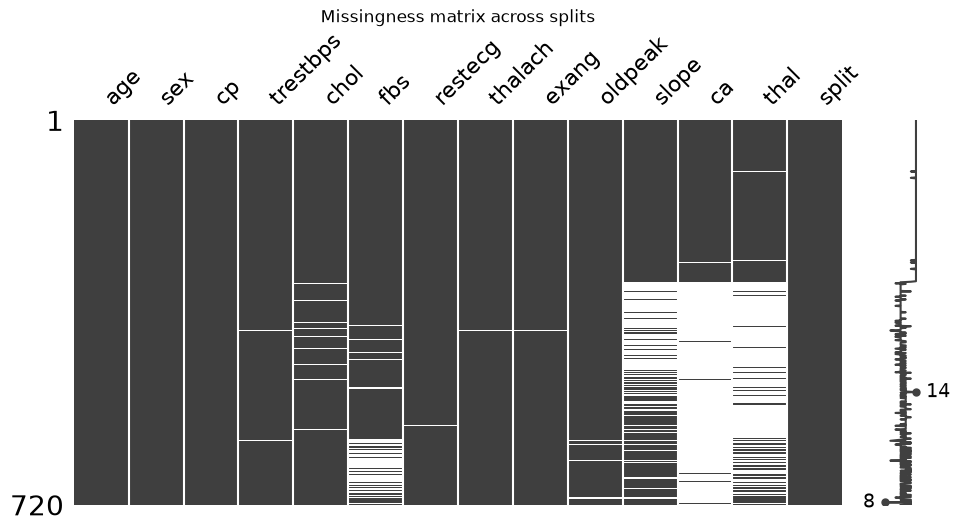

In [7]:
try:
    import missingno as msno
    combined = pd.concat([df.assign(split=name) for name, df in splits.items()], ignore_index=True)
    msno.matrix(combined[RAW_FEATURES + ["split"]], figsize=(11, 5))
    plt.title("Missingness matrix across splits")
    plt.show()
except ImportError:
    combined = pd.concat([df.assign(split=name) for name, df in splits.items()], ignore_index=True)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(combined[RAW_FEATURES].isna(), aspect="auto")
    ax.set_title("Missingness matrix across splits")
    ax.set_xticks(range(len(RAW_FEATURES)))
    ax.set_xticklabels(RAW_FEATURES, rotation=90)
    plt.tight_layout()
    plt.show()

## Cleveland train feature distributions by label

These plots use Cleveland train only. They support clinical interpretation without looking at held-out test outcomes.

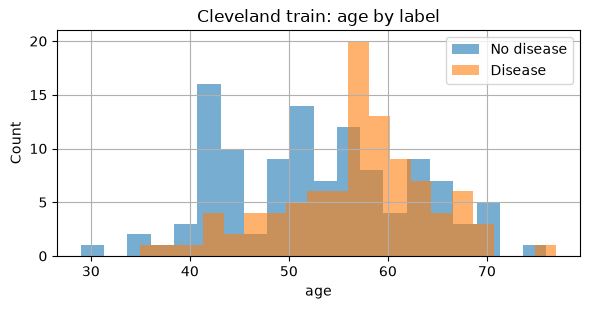

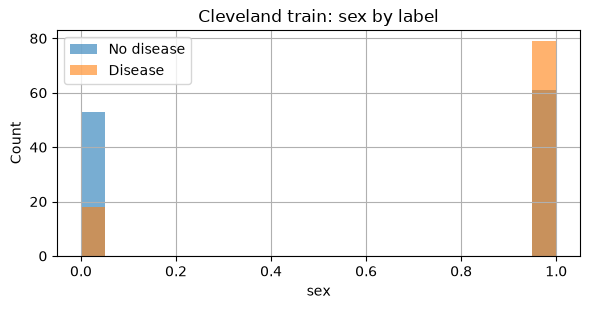

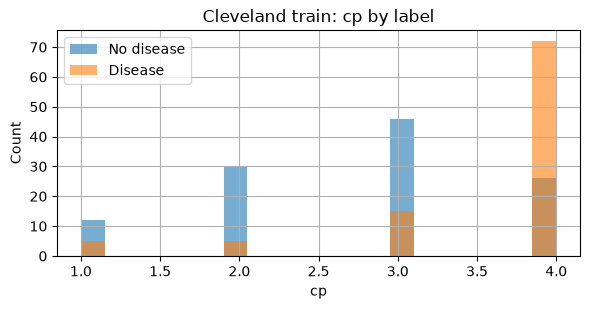

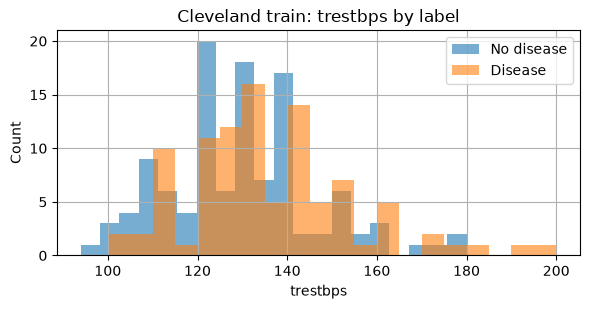

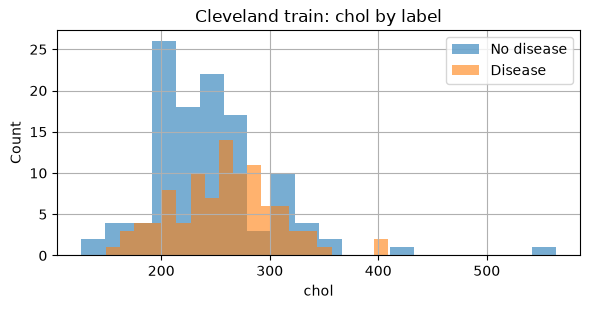

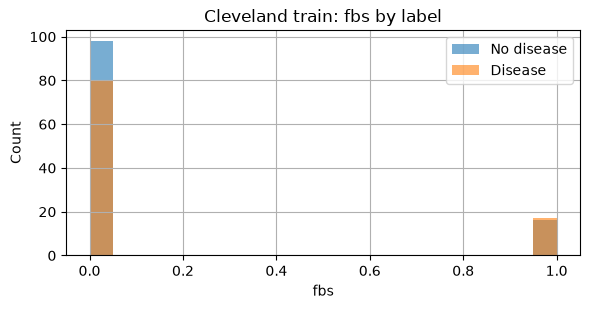

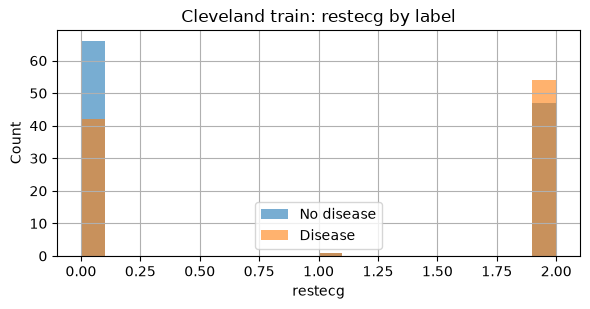

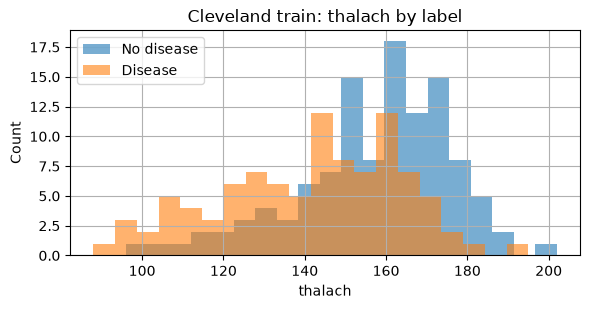

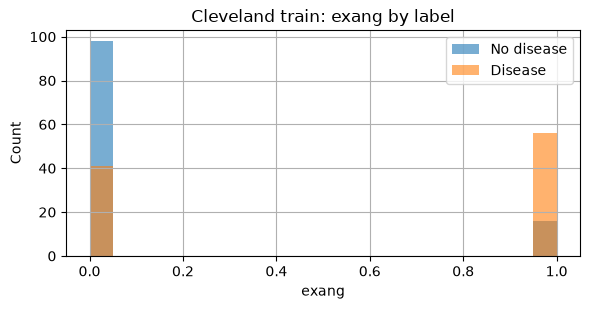

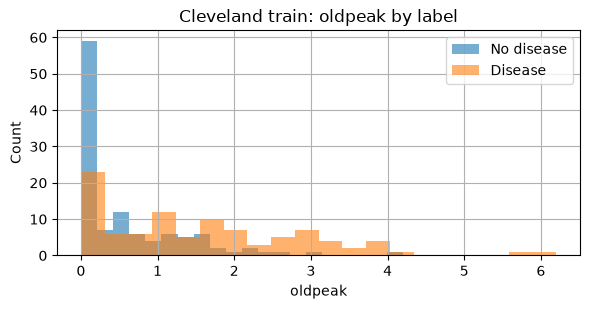

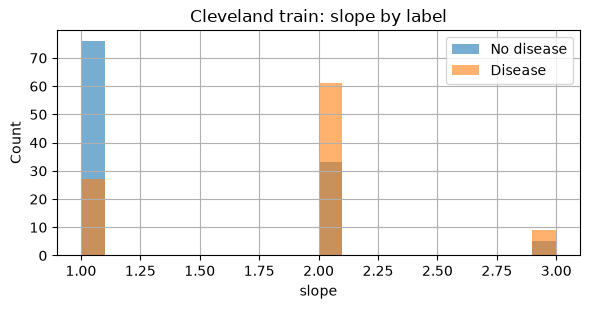

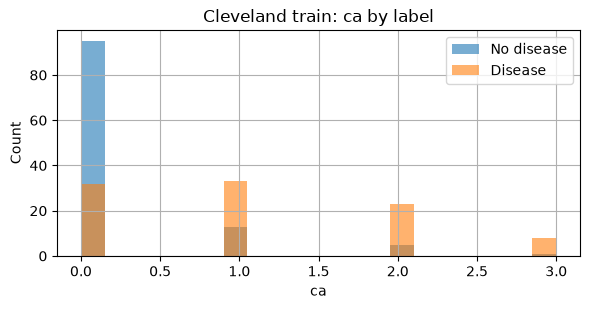

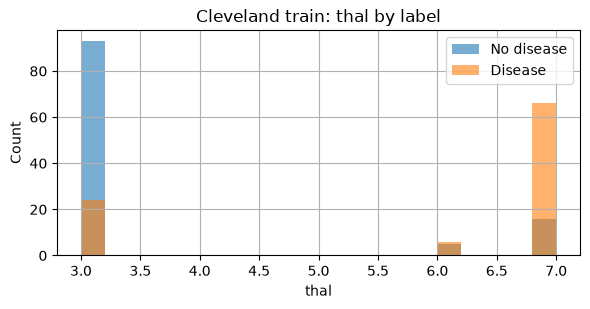

In [8]:
for col in RAW_FEATURES:
    fig, ax = plt.subplots(figsize=(6, 3.2))
    train.loc[train["target"] == 0, col].dropna().hist(bins=20, alpha=0.6, ax=ax, label="No disease")
    train.loc[train["target"] == 1, col].dropna().hist(bins=20, alpha=0.6, ax=ax, label="Disease")
    ax.set_title(f"Cleveland train: {col} by label")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Cleveland train correlation matrix

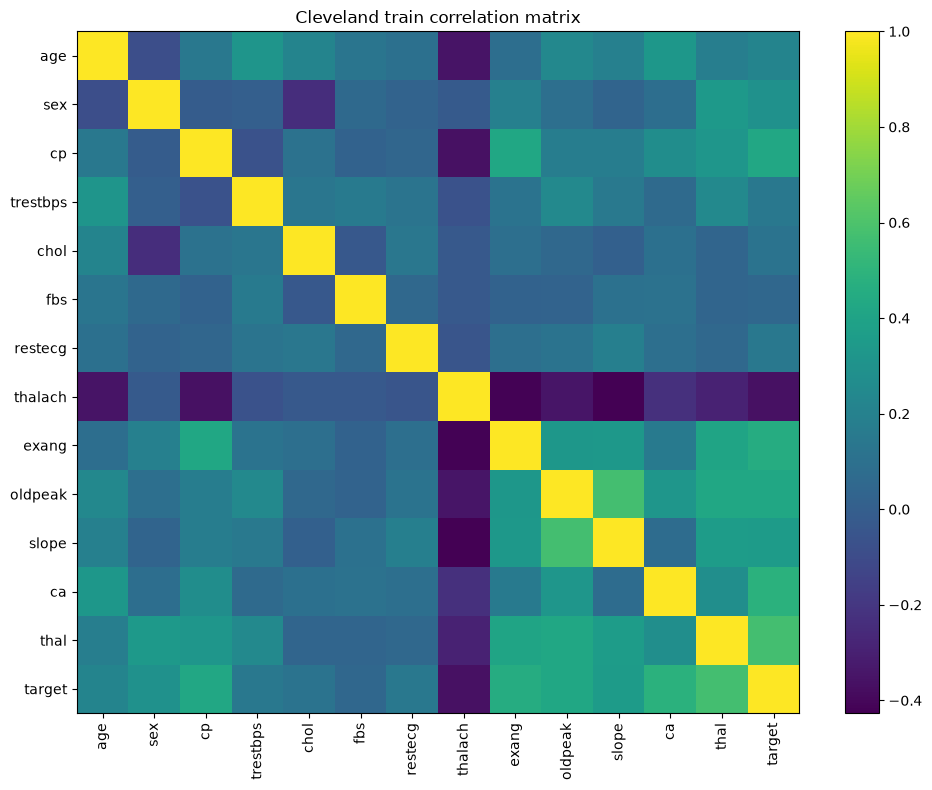

target      1.000000
thal        0.576330
ca          0.482532
exang       0.459320
cp          0.429754
oldpeak     0.422758
slope       0.355094
sex         0.294636
age         0.214941
trestbps    0.146887
restecg     0.145489
chol        0.115427
fbs         0.047894
thalach    -0.360305
Name: target, dtype: float64

In [9]:
corr = train[RAW_FEATURES + ["target"]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
ax.set_title("Cleveland train correlation matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

corr["target"].sort_values(ascending=False)

## Cross-site covariate shift screening

The source distribution is Cleveland train. External targets are compared feature-by-feature using chi-square tests for low-cardinality variables and KS tests for higher-cardinality variables. The held-out Cleveland test is excluded from this shift table to avoid using it for modeling decisions.

In [10]:
def is_low_cardinality(series, threshold=10):
    return pd.to_numeric(series, errors="coerce").dropna().nunique() <= threshold

def compare_shift(source, target, feature):
    a = pd.to_numeric(source[feature], errors="coerce").dropna()
    b = pd.to_numeric(target[feature], errors="coerce").dropna()
    if len(a) == 0 or len(b) == 0:
        return {"test": "not_available", "statistic": np.nan, "p_value": np.nan, "source_mean": np.nan, "target_mean": np.nan, "mean_delta": np.nan}
    if is_low_cardinality(pd.concat([a, b])):
        vals = sorted(set(a.unique()).union(set(b.unique())))
        obs = np.array([[(a == v).sum() for v in vals], [(b == v).sum() for v in vals]])
        try:
            stat, p, _, _ = stats.chi2_contingency(obs)
        except ValueError:
            stat, p = np.nan, np.nan
        test_name = "chi_square"
    else:
        stat, p = stats.ks_2samp(a, b)
        test_name = "ks_2samp"
    return {"test": test_name, "statistic": stat, "p_value": p, "source_mean": a.mean(), "target_mean": b.mean(), "mean_delta": b.mean() - a.mean()}

shift_rows = []
for target_name, target_df in {"Hungarian": hungarian, "Swiss": swiss}.items():
    for feature in RAW_FEATURES:
        shift_rows.append({"comparison": f"Cleveland_train_vs_{target_name}", "feature": feature, **compare_shift(train, target_df, feature)})

distribution_shift_summary = pd.DataFrame(shift_rows).sort_values(["comparison", "p_value"])
distribution_shift_summary

,comparison,feature,test,statistic,p_value,source_mean,target_mean,mean_delta
6,Cleveland_train_vs_Hungarian,restecg,chi_square,168.792205,2.224531e-37,0.966825,0.218430,-0.748395
0,Cleveland_train_vs_Hungarian,age,ks_2samp,0.370329,1.577050e-15,54.734597,47.826531,-6.908067
10,Cleveland_train_vs_Hungarian,slope,chi_square,53.105518,2.939566e-12,1.578199,1.894231,0.316032
9,Cleveland_train_vs_Hungarian,oldpeak,ks_2samp,0.320582,1.099344e-11,1.034123,0.586054,-0.448069
7,Cleveland_train_vs_Hungarian,thalach,ks_2samp,0.279378,6.044375e-09,150.165877,139.129693,-11.036184
12,Cleveland_train_vs_Hungarian,thal,chi_square,30.480095,2.406199e-07,4.719048,5.642857,0.923810
2,Cleveland_train_vs_Hungarian,cp,chi_square,27.389930,4.877021e-06,3.137441,2.982993,-0.154448
5,Cleveland_train_vs_Hungarian,fbs,chi_square,8.643198,3.282847e-03,0.156398,0.069930,-0.086468
1,Cleveland_train_vs_Hungarian,sex,chi_square,1.891105,1.690773e-01,0.663507,0.724490,0.060983
4,Cleveland_train_vs_Hungarian,chol,ks_2samp,0.088369,2.896632e-01,250.582938,250.848708,0.265770
